In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set aesthetics for academic publications
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'sans-serif'
})

In [2]:
df_raw = pd.read_csv('evaluations_full_metrics.csv')
df_raw.head(2)

,Evaluation ID,Created At,Query,Model A,Model B,A_Step1_Embedding,A_Step2_Shortlist,A_Step3_Rerank,A_Step4_FetchDB,A_Step5_Aggregate,...,B_Step3_Rerank,B_Step4_FetchDB,B_Step5_Aggregate,B_Step6_Format,B_Total,Results Identical,Evaluator Type,Preference Submitted,Winner,Reasoning
0,1346,2026-05-30 18:59:50.131365+00:00,I need a specialist in epidemiological modelin...,64_dim,768_dim,0.054417,0.038866,0.003538,0.018307,0.001025,...,0.000000,0.017920,0.000809,0.000213,0.148944,False,llm,True,768_dim,List B is significantly superior because all t...
1,1345,2026-05-30 18:59:30.907508+00:00,I need a specialist in epidemiological modelin...,64_dim,512_dim,0.054417,0.038866,0.003538,0.018307,0.001025,...,0.002998,0.017721,0.000845,0.000219,0.104484,False,llm,True,512_dim,List B is far superior because all three exper...


In [3]:
df_llm = df_raw[(df_raw['Evaluator Type'] == 'llm') & (df_raw['Preference Submitted'] == True)].copy()
print(f"Using {len(df_llm)} LLM evaluation records.")

Using 264 LLM evaluation records.


In [4]:
# Extract isolated runs for Model A
df_a = df_llm[['Query', 'Model A', 'A_Step2_Shortlist', 'A_Step3_Rerank']].copy()
df_a.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Extract isolated runs for Model B
df_b = df_llm[['Query', 'Model B', 'B_Step2_Shortlist', 'B_Step3_Rerank']].copy()
df_b.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Combine datasets and calculate total Vector Latency (Shortlisting + Reranking)
df_combined = pd.concat([df_a, df_b], ignore_index=True)
df_combined['Vector_Latency'] = df_combined['Step2_Shortlist'] + df_combined['Step3_Rerank']

# Parse numerical dimensions
df_combined['Dim_Num'] = df_combined['Dimension'].apply(lambda x: int(str(x).split('_')[0]))

# Deduplicate to maintain exactly one record per unique Query and Dimension
df_latency = df_combined.drop_duplicates(subset=['Query', 'Dim_Num']).copy()

print(f"Deduplicated observations: {len(df_latency)} (Expected: 500 for 100 queries x 5 dimensions)")
print(df_latency.groupby('Dim_Num')['Vector_Latency'].describe())

Deduplicated observations: 135 (Expected: 500 for 100 queries x 5 dimensions)
         count      mean       std       min       25%       50%       75%  \
Dim_Num                                                                      
64        27.0  0.156466  0.127632  0.042404  0.058485  0.095417  0.211525   
128       27.0  0.148617  0.121930  0.028337  0.051803  0.094415  0.222688   
256       27.0  0.158966  0.109807  0.033056  0.075959  0.111010  0.222490   
512       27.0  0.172334  0.109061  0.031282  0.089201  0.134361  0.231523   
768       27.0  0.191702  0.106770  0.056018  0.120770  0.148758  0.260800   

              max  
Dim_Num            
64       0.551721  
128      0.446540  
256      0.398448  
512      0.387552  
768      0.419222  


## How does vector truncation affect latency, and is the speedup statistically significant?

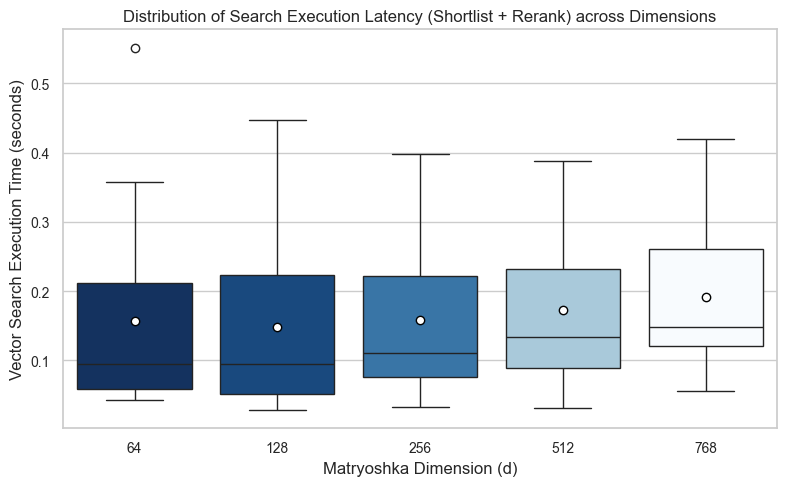

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_latency, 
    x='Dim_Num', 
    y='Vector_Latency', 
    palette="Blues_r",
    hue="Dim_Num",
    legend=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)
plt.title('Distribution of Search Execution Latency (Shortlist + Rerank) across Dimensions')
plt.xlabel('Matryoshka Dimension (d)')
plt.ylabel('Vector Search Execution Time (seconds)')
plt.tight_layout()
plt.savefig('mrl_latency_boxplot.png', dpi=300)
plt.show()

In [6]:
# Perform Shapiro-Wilk test for normality on residuals
grouped_data = [group['Vector_Latency'].values for name, group in df_latency.groupby('Dim_Num')]
f_stat, p_val_anova = stats.f_oneway(*grouped_data)

print(f"One-way ANOVA F-Statistic: {f_stat:.4f}")
print(f"One-way ANOVA p-value: {p_val_anova:.4e}")

if p_val_anova < 0.05:
    print("Result: Highly significant. Reject the null hypothesis. Proceeding to post-hoc analysis...")
else:
    print("Result: No significant difference detected.")

One-way ANOVA F-Statistic: 0.5798
One-way ANOVA p-value: 6.7782e-01
Result: No significant difference detected.


In [7]:
# Pairwise Tukey's HSD test
tukey = pairwise_tukeyhsd(
    endog=df_latency['Vector_Latency'],
    groups=df_latency['Dim_Num'],
    alpha=0.05
)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    64    128  -0.0078 0.9991 -0.0947  0.079  False
    64    256   0.0025    1.0 -0.0843 0.0893  False
    64    512   0.0159 0.9867  -0.071 0.1027  False
    64    768   0.0352 0.7944 -0.0516 0.1221  False
   128    256   0.0103 0.9974 -0.0765 0.0972  False
   128    512   0.0237 0.9427 -0.0631 0.1106  False
   128    768   0.0431 0.6463 -0.0438 0.1299  False
   256    512   0.0134 0.9931 -0.0735 0.1002  False
   256    768   0.0327 0.8349 -0.0541 0.1196  False
   512    768   0.0194 0.9722 -0.0675 0.1062  False
---------------------------------------------------


## Quality Analysis

In [8]:
def compute_elo(matches, K=32, init_elo=1000.0):
    """
    Computes ELO ratings from a series of pairwise matchups.
    """
    dimensions = ['64_dim', '128_dim', '256_dim', '512_dim', '768_dim']
    elos = {dim: init_elo for dim in dimensions}
    
    for _, row in matches.iterrows():
        m_a = row['Model A']
        m_b = row['Model B']
        winner = row['Winner']
        
        # Set actual scores
        if winner == m_a:
            S_a, S_b = 1.0, 0.0
        elif winner == m_b:
            S_a, S_b = 0.0, 1.0
        else: # Draw
            S_a, S_b = 0.5, 0.5
            
        r_a, r_b = elos[m_a], elos[m_b]
        
        # Expected scores
        E_a = 1.0 / (1.0 + 10.0 ** ((r_b - r_a) / 400.0))
        E_b = 1.0 / (1.0 + 10.0 ** ((r_a - r_b) / 400.0))
        
        # ELO updates
        elos[m_a] = r_a + K * (S_a - E_a)
        elos[m_b] = r_b + K * (S_b - E_b)
        
    return elos

### Bootstrapping Tournament matches (Monte Carlo)
To eliminate bias introduced by sequence order and output standard errors for ELO.

In [9]:
n_iterations = 1000
bootstrap_elos = []

for i in range(n_iterations):
    # Sample matches randomly with replacement
    df_sampled = df_llm.sample(frac=1.0, replace=True, random_state=727 + i)
    elos = compute_elo(df_sampled)
    bootstrap_elos.append(elos)

In [10]:
df_boot = pd.DataFrame(bootstrap_elos)
df_boot_summary = pd.DataFrame({
    'Mean_ELO': df_boot.mean(),
    'Std_Error': df_boot.std(),
    'CI_Lower': df_boot.quantile(0.025),
    'CI_Upper': df_boot.quantile(0.975)
}).sort_values('Mean_ELO', ascending=False)

# Parse numerical values for regression/correlation
df_boot_summary['Dim_Num'] = [int(idx.split('_')[0]) for idx in df_boot_summary.index]
df_boot_summary = df_boot_summary.sort_values('Dim_Num')

print("Bootstrapped ELO Rating Results (95% Confidence Interval):")
print(df_boot_summary)

Bootstrapped ELO Rating Results (95% Confidence Interval):
            Mean_ELO  Std_Error    CI_Lower     CI_Upper  Dim_Num
64_dim    840.622938  46.733352  751.014764   932.453897       64
128_dim  1047.517071  44.004352  963.674203  1130.762075      128
256_dim  1030.424380  45.551996  938.382369  1114.583316      256
512_dim  1026.083625  44.650259  937.258415  1111.523853      512
768_dim  1055.351986  43.909118  968.962499  1137.888937      768


Saved ELO chart to 'mrl_quality_elo_bar.png'.


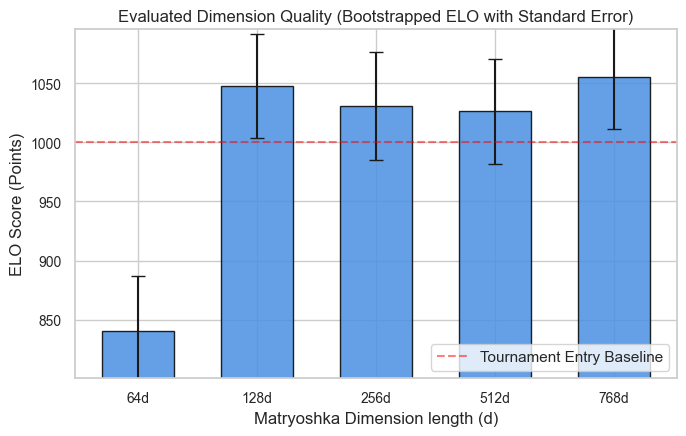

In [11]:
plt.figure(figsize=(7, 4.5))
plt.bar(
    x=[f"{dim}d" for dim in df_boot_summary['Dim_Num']],
    height=df_boot_summary['Mean_ELO'],
    yerr=df_boot_summary['Std_Error'],
    color='#4a90e2',
    edgecolor='black',
    capsize=5,
    alpha=0.85,
    width=0.6
)
plt.axhline(1000, color='red', linestyle='--', alpha=0.5, label='Tournament Entry Baseline')
plt.title('Evaluated Dimension Quality (Bootstrapped ELO with Standard Error)', fontsize=12)
plt.xlabel('Matryoshka Dimension length (d)')
plt.ylabel('ELO Score (Points)')
plt.ylim(df_boot_summary['Mean_ELO'].min() - 40, df_boot_summary['Mean_ELO'].max() + 40)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('mrl_quality_elo_bar.png')
print("Saved ELO chart to 'mrl_quality_elo_bar.png'.")

In [12]:
corr_coef, corr_p = stats.spearmanr(df_boot_summary['Dim_Num'], df_boot_summary['Mean_ELO'])
print(f"Spearman's Rank Correlation (Dim_Num vs Mean_ELO): {corr_coef:.6f}")
print(f"Spearman's p-value: {corr_p:.6f}")

Spearman's Rank Correlation (Dim_Num vs Mean_ELO): 0.600000
Spearman's p-value: 0.284757


## The Pareto Efficiency Frontier (Trade-Off Optimization)
Merging ELO scores and execution latency averages to find the optimal deployment model.

In [13]:
# Calculate deterministic mean latencies
mean_latency = df_latency.groupby('Dim_Num')['Vector_Latency'].mean().reset_index()
df_pareto = pd.merge(df_boot_summary, mean_latency, on='Dim_Num')

print("\nPareto Frontier Coordinates:")
for _, row in df_pareto.iterrows():
    print(f"Dimension: {int(row['Dim_Num']):>3} | Latency: {row['Vector_Latency']:.5f}s | ELO: {row['Mean_ELO']:.2f}")


Pareto Frontier Coordinates:
Dimension:  64 | Latency: 0.15647s | ELO: 840.62
Dimension: 128 | Latency: 0.14862s | ELO: 1047.52
Dimension: 256 | Latency: 0.15897s | ELO: 1030.42
Dimension: 512 | Latency: 0.17233s | ELO: 1026.08
Dimension: 768 | Latency: 0.19170s | ELO: 1055.35


Saved Pareto Frontier to 'mrl_pareto_frontier.png'.


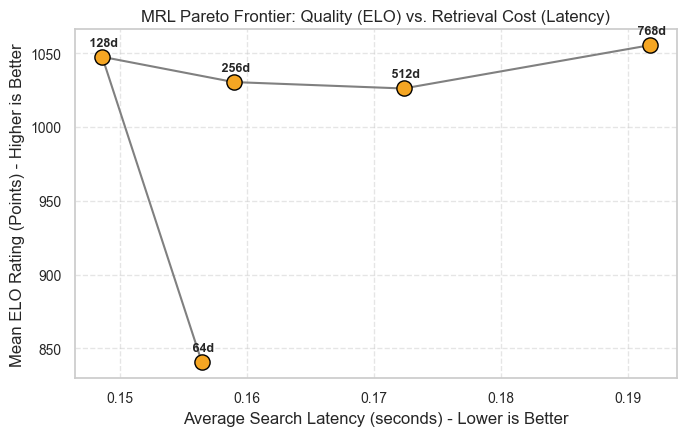

In [14]:
plt.figure(figsize=(7, 4.5))
plt.scatter(
    df_pareto['Vector_Latency'], 
    df_pareto['Mean_ELO'], 
    color='#f5a623', 
    s=120, 
    edgecolor='black',
    zorder=3
)
plt.plot(
    df_pareto['Vector_Latency'], 
    df_pareto['Mean_ELO'], 
    color='grey', 
    linestyle='-', 
    linewidth=1.5,
    zorder=2
)

# Label data points
for _, row in df_pareto.iterrows():
    plt.annotate(
        f" {int(row['Dim_Num'])}d", 
        (row['Vector_Latency'], row['Mean_ELO']),
        textcoords="offset points", 
        xytext=(0, 8), 
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('MRL Pareto Frontier: Quality (ELO) vs. Retrieval Cost (Latency)', fontsize=12)
plt.xlabel('Average Search Latency (seconds) - Lower is Better')
plt.ylabel('Mean ELO Rating (Points) - Higher is Better')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('mrl_pareto_frontier.png')
print("Saved Pareto Frontier to 'mrl_pareto_frontier.png'.")